In [13]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C://Users//Acer//OneDrive//Desktop//Datasets//student-lifestyle-and-stress-dataset.csv")
df.sample(5)

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
12254,college,2.713051,8.161214,5.576322,80.790918,3.0,9.0,2.0,0
16637,working_student,NaN,5.785492,4.323122,88.552246,2.0,6.0,12.0,0
22583,working_student,7.917663,5.606544,2.240414,99.023751,6.0,7.0,6.0,0
6593,working_student,4.475281,8.025670,3.526936,91.620683,3.0,8.0,6.0,0
6426,school,8.324366,1.238387,1.627894,93.571565,7.0,6.0,6.0,0


In [3]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        24248 non-null  str    
 1   Sleep_Hours         24167 non-null  float64
 2   Study_Hours         24223 non-null  float64
 3   Social_Media_Hours  24188 non-null  float64
 4   Attendance          24195 non-null  float64
 5   Exam_Pressure       24230 non-null  float64
 6   Family_Support      24209 non-null  float64
 7   Month               24186 non-null  float64
 8   Stress_Level        25500 non-null  int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 1.9 MB


(25500, 9)

In [4]:
df = df.dropna()

In [5]:
df.shape

(16809, 9)

In [6]:
# x --> features and y --> target
x = df.drop(columns=['Stress_Level'])
y = df['Stress_Level']

In [7]:
# Train test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train.head()

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month
7467,college,6.528006,6.036766,4.338599,86.363661,5.0,7.0,3.0
14984,college,4.053333,5.750771,7.836553,84.269610,4.0,6.0,10.0
22517,school,7.724674,3.749814,3.775663,98.024832,3.0,5.0,8.0
888,college,3.618676,4.743576,2.685517,83.819919,10.0,7.0,1.0
14632,college,7.570497,6.234339,0.544889,95.471733,1.0,3.0,6.0


In [8]:
# One hot encoding the training set's categorical value:-
ohe = OneHotEncoder(sparse_output=False,drop='first')
encoded_train = ohe.fit_transform(x_train[['Student_Type']])
encoded_df_train = pd.DataFrame(
    encoded_train,
    columns=ohe.get_feature_names_out(['Student_Type']),
    index=x_train.index
)
x_train = pd.concat([x_train.drop('Student_Type', axis=1), encoded_df_train], axis=1)

# Test set One hot encoding:-
encoded_test = ohe.transform(x_test[['Student_Type']])
encoded_df_test = pd.DataFrame(
    encoded_test,
    columns=ohe.get_feature_names_out(['Student_Type']),
    index=x_test.index
)
x_test = pd.concat([x_test.drop('Student_Type', axis=1), encoded_df_test], axis=1)

In [11]:
# fitting data and calculating cross val score:
clf = AdaBoostClassifier(n_estimators=500,learning_rate=1.0,random_state=42) # taken from grid search cv
clf.fit(x_train,y_train)
cv = cross_val_score(clf,x_train,y_train,cv=7,scoring='accuracy')
print(f"CV score is {np.mean(cv)}")

# accuracy on test set:

print(f"Accuracy is {accuracy_score(y_test,clf.predict(x_test))}")

CV score is 0.8224139213207406
Accuracy is 0.8197501487209994


In [10]:
# Grid search cv for getting best parameters value:
estimator = AdaBoostClassifier(random_state=42)
grid = dict()
grid['n_estimators'] = [100,200,300,400,500,1000]
grid['learning_rate'] = [0.25,0.5,0.75,1.0,2,3]

grid_search = GridSearchCV(estimator=estimator,param_grid=grid,scoring='accuracy',
                        cv=7,n_jobs=-1)
grid_search.fit(x_train,y_train)

print(f"Best parameters are {grid_search.best_params_}")
print(f"Best score in {grid_search.best_score_}")


Best parameters are {'learning_rate': 1.0, 'n_estimators': 500}
Best score in 0.8224139213207406


In [16]:
def visualize(x_train,y_train,x_test,y_test,n_estimators = 100,learning_rate = 1.0):
    # PCA for visualization
    pca = PCA(n_components=2)
    x_train = pca.fit_transform(x_train)
    x_test = pca.transform(x_test)

    y_train = np.array(y_train)
    y_test = np.array(y_test)
    # Model training
    est = AdaBoostClassifier(n_estimators=n_estimators,learning_rate=learning_rate)
    est.fit(x_train,y_train)

    # Accuracy on test set:
    y_pred = est.predict(x_test)
    print(f"Accuracy on test set is {accuracy_score(y_test,y_pred)}")

    # Plot:
    plt.figure(figsize=(12,6))
    # Training plot
    plt.subplot(121)
    plot_decision_regions(x_train,y_train,clf=est)
    plt.title("Training set")
    # Test plot
    plt.subplot(122)
    plot_decision_regions(x_test,y_test,clf=est)
    plt.title("Test set")

    plt.show()

Accuracy on test set is 0.7061273051754908


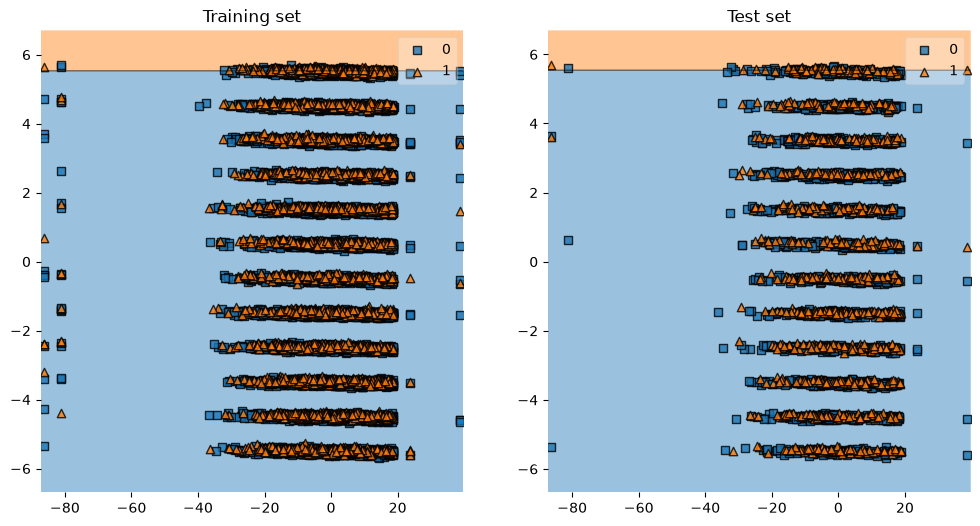

In [18]:
visualize(x_train,y_train,x_test,y_test,n_estimators=500,learning_rate=1.0)

In the given dataset n_components = 2 is not working well...There is lot of overlapping in datapoints therefore you can use this function on some other dataset.